### Lab 4 - Thresholding and Histogram Processing

##  *Task 1: Percentile Rescaling* 🛠️


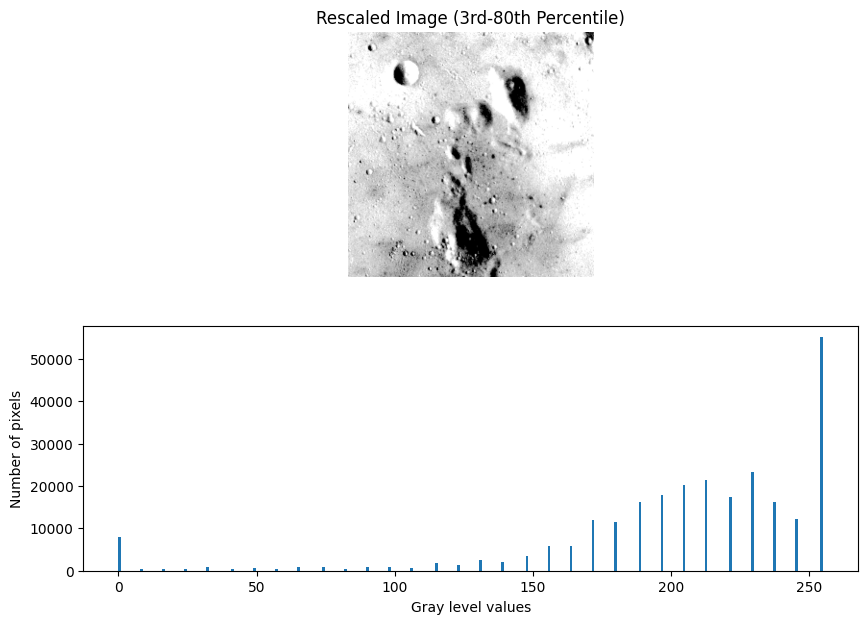

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposure

# Load the moon image
img = data.moon()

# Calculate the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))

# Rescale intensity
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
ax1.imshow(img_rescale, cmap='gray')
ax1.set_title('Rescaled Image (3rd-80th Percentile)')
ax1.axis('off')

ax2.hist(img_rescale.flat, bins=256, range=(0, 255))
ax2.set_xlabel('Gray level values')
ax2.set_ylabel('Number of pixels')
plt.show()

##  *Task 2: Histogram Equalization* ⚖️


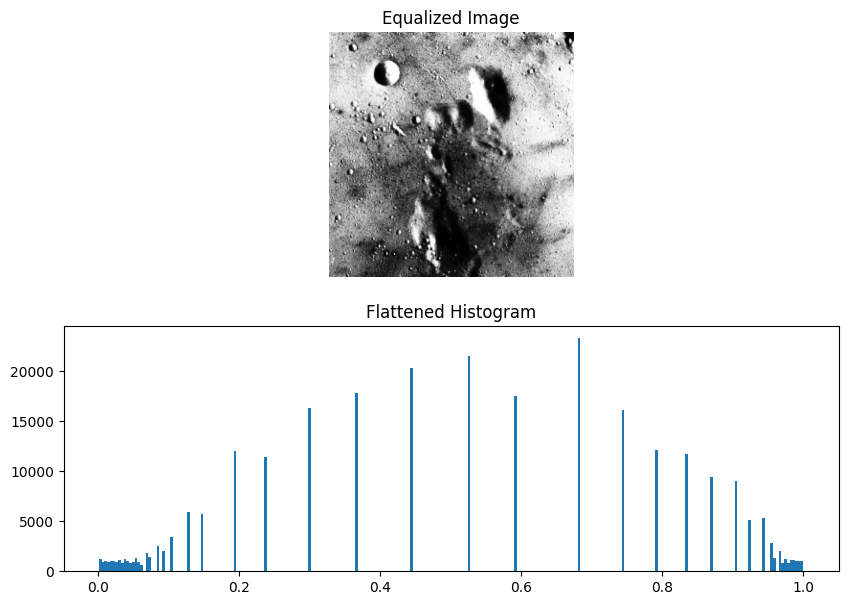

In [2]:
# Apply Histogram Equalization
img_eq = exposure.equalize_hist(img)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
ax1.imshow(img_eq, cmap='gray')
ax1.set_title('Equalized Image')
ax1.axis('off')

# Note: equalize_hist returns values in range [0, 1]
ax2.hist(img_eq.flat, bins=256)
ax2.set_title('Flattened Histogram')
plt.show()

## *Task 3: Histogram Matching* 🔄

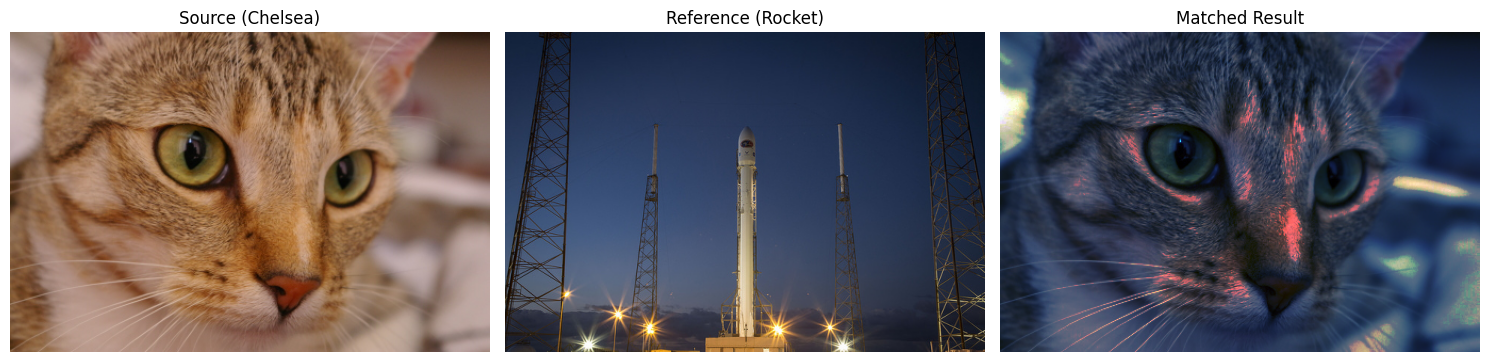

In [3]:
from skimage.exposure import match_histograms

# Load the source (chelsea the cat) and reference (rocket)
source = data.chelsea()
reference = data.rocket()

# Perform Histogram Matching
# multichannel=True (or channel_axis=-1 in newer versions) for color images
matched = match_histograms(source, reference, channel_axis=-1)

# Display results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(source)
ax1.set_title('Source (Chelsea)')
ax2.imshow(reference)
ax2.set_title('Reference (Rocket)')
ax3.imshow(matched)
ax3.set_title('Matched Result')

for ax in [ax1, ax2, ax3]:
    ax.axis('off')

plt.tight_layout()
plt.show()